# 09 — Backtesting

**BBL514E Pattern Recognition — Term Project (MVP)**

## hedef
Notebook 07'de üretilen test set sinyallerini gerçek BTC fiyatları üzerinde simüle et.
Long-only strateji: `Buy → enter long`, `Sell → exit`, `Hold → no-op`.

## metrikler (MVP)
- Cumulative return
- Annualized return
- Sharpe ratio (annualized)
- Maximum drawdown
- Number of trades, win rate
- Equity curve (vs Buy & Hold benchmark)

## işlem maliyetleri
- Transaction fee: 0.1% (config'den)
- Slippage: 0.05%
- Maliyetli vs maliyetsiz karşılaştırma raporlanır.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)

from src.utils.config import cfg
from src.utils.helpers import save_csv
from src.evaluation.backtester import Backtester

config = cfg()

In [2]:
btc = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "btc_aligned.csv", index_col=0, parse_dates=True)
test_signals = pd.read_csv(PROJECT_ROOT / "data" / "labels" / "btc_test_signals.csv", index_col=0, parse_dates=True)

print(f"Test signals: {test_signals.shape}")
print(f"Test period: {test_signals.index.min().date()} → {test_signals.index.max().date()}")
print(test_signals.head(3))

Test signals: (505, 9)
Test period: 2024-08-03 → 2025-12-25
           lda_pred mlp_pred y_true  lda_proba_Buy  mlp_proba_Buy  \
Date                                                                
2024-08-03     Sell     Sell    Buy       0.229806       0.001222   
2024-08-04     Sell     Sell    Buy       0.240650       0.143313   
2024-08-05     Sell      Buy    Buy       0.326985       0.516790   

            lda_proba_Hold  mlp_proba_Hold  lda_proba_Sell  mlp_proba_Sell  
Date                                                                        
2024-08-03        0.156587        0.001005        0.613607        0.997773  
2024-08-04        0.169397        0.179124        0.589953        0.677562  
2024-08-05        0.117138        0.091214        0.555878        0.391997  


In [3]:
# Align prices to test period
test_prices = btc["Close"].loc[test_signals.index]
print(f"Test prices: {len(test_prices)} days, {test_prices.iloc[0]:.0f} → {test_prices.iloc[-1]:.0f}")
print(f"Buy&Hold raw return: {(test_prices.iloc[-1] / test_prices.iloc[0] - 1) * 100:+.2f}%")

Test prices: 505 days, 60680 → 87235
Buy&Hold raw return: +43.76%


## 1. LDA backtest

In [4]:
lda_signals = test_signals["lda_pred"]
mlp_signals = test_signals["mlp_pred"]

# With transaction costs
bt_with_cost = Backtester()
lda_with = bt_with_cost.run(lda_signals, test_prices)
mlp_with = bt_with_cost.run(mlp_signals, test_prices)

# Without transaction costs
bt_no_cost = Backtester(transaction_fee=0.0, slippage=0.0)
lda_no = bt_no_cost.run(lda_signals, test_prices)
mlp_no = bt_no_cost.run(mlp_signals, test_prices)

# Buy & hold benchmark
bh_equity = bt_with_cost.run_buy_and_hold(test_prices)

summary = pd.DataFrame([
    {"strategy": "LDA (with cost)", **{k: v for k, v in lda_with.items() if isinstance(v, (int, float))}},
    {"strategy": "LDA (no cost)", **{k: v for k, v in lda_no.items() if isinstance(v, (int, float))}},
    {"strategy": "MLP (with cost)", **{k: v for k, v in mlp_with.items() if isinstance(v, (int, float))}},
    {"strategy": "MLP (no cost)", **{k: v for k, v in mlp_no.items() if isinstance(v, (int, float))}},
    {"strategy": "Buy & Hold", "total_return": bh_equity.iloc[-1] / bh_equity.iloc[0] - 1,
     "sharpe_ratio": (test_prices.pct_change().mean() / test_prices.pct_change().std() * np.sqrt(252)),
     "max_drawdown": ((bh_equity - bh_equity.cummax()) / bh_equity.cummax()).min(),
     "n_trades": 1, "win_rate": np.nan, "profit_factor": np.nan},
])
summary = summary.set_index("strategy").round(4)
print(summary[["total_return", "annualized_return", "sharpe_ratio", "max_drawdown", "n_trades", "win_rate"]].fillna("-").to_string())

2026-05-07 19:56:31 | src.evaluation.backtester | INFO | Backtest: return=0.00%, sharpe=0.00, maxDD=0.00%, trades=0, win_rate=0.00%


2026-05-07 19:56:31 | src.evaluation.backtester | INFO | Backtest: return=15.82%, sharpe=0.55, maxDD=-15.85%, trades=26, win_rate=53.85%


2026-05-07 19:56:31 | src.evaluation.backtester | INFO | Backtest: return=0.00%, sharpe=0.00, maxDD=0.00%, trades=0, win_rate=0.00%


2026-05-07 19:56:31 | src.evaluation.backtester | INFO | Backtest: return=15.82%, sharpe=0.55, maxDD=-15.85%, trades=26, win_rate=53.85%


                 total_return annualized_return  sharpe_ratio  max_drawdown  n_trades win_rate
strategy                                                                                      
LDA (with cost)        0.0000               0.0        0.0000        0.0000         0      0.0
LDA (no cost)          0.0000               0.0        0.0000        0.0000         0      0.0
MLP (with cost)        0.1582             0.076        0.5531       -0.1585        26   0.5385
MLP (no cost)          0.1582             0.076        0.5531       -0.1585        26   0.5385
Buy & Hold             0.4376                 -        0.6653       -0.3215         1        -


## 2. Equity curves

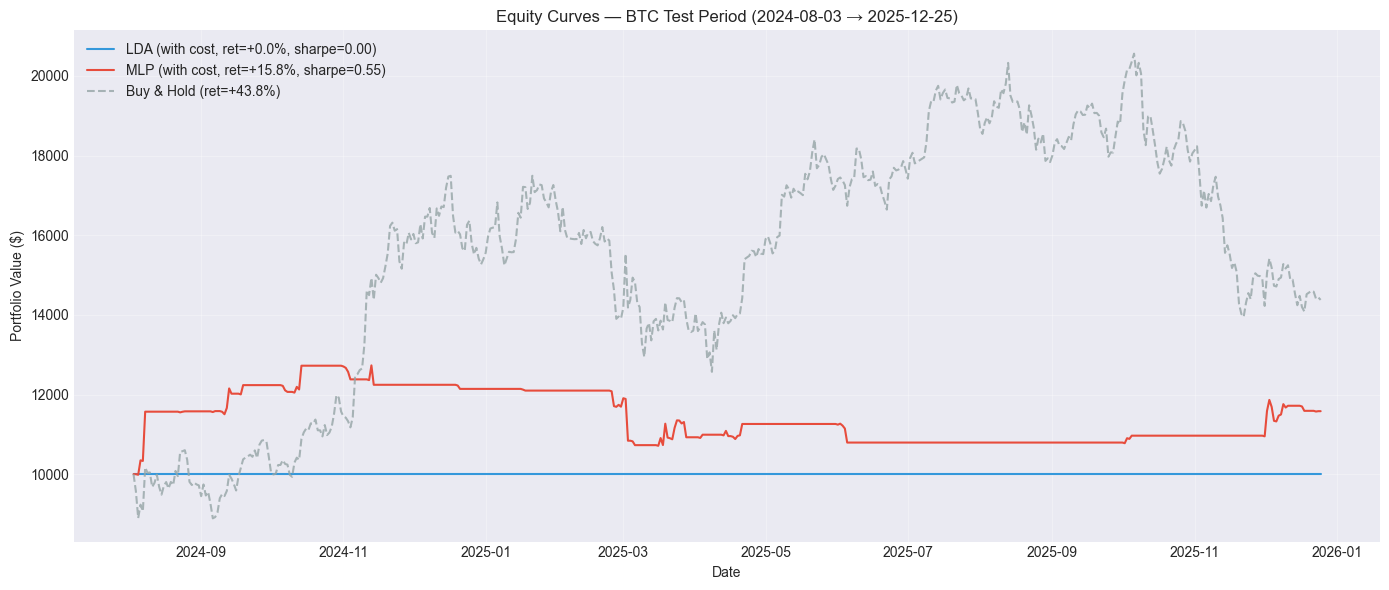

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

ax.plot(lda_with["equity_curve"].index, lda_with["equity_curve"].values,
        label=f"LDA (with cost, ret={lda_with['total_return']:+.1%}, sharpe={lda_with['sharpe_ratio']:.2f})",
        linewidth=1.5, color="#3498DB")
ax.plot(mlp_with["equity_curve"].index, mlp_with["equity_curve"].values,
        label=f"MLP (with cost, ret={mlp_with['total_return']:+.1%}, sharpe={mlp_with['sharpe_ratio']:.2f})",
        linewidth=1.5, color="#E74C3C")
ax.plot(bh_equity.index, bh_equity.values,
        label=f"Buy & Hold (ret={bh_equity.iloc[-1]/bh_equity.iloc[0]-1:+.1%})",
        linewidth=1.5, color="#95A5A6", linestyle="--", alpha=0.8)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.set_title(f"Equity Curves — BTC Test Period ({test_signals.index.min().date()} → {test_signals.index.max().date()})")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "backtest_equity_curves.png", dpi=120, bbox_inches="tight")
plt.show()

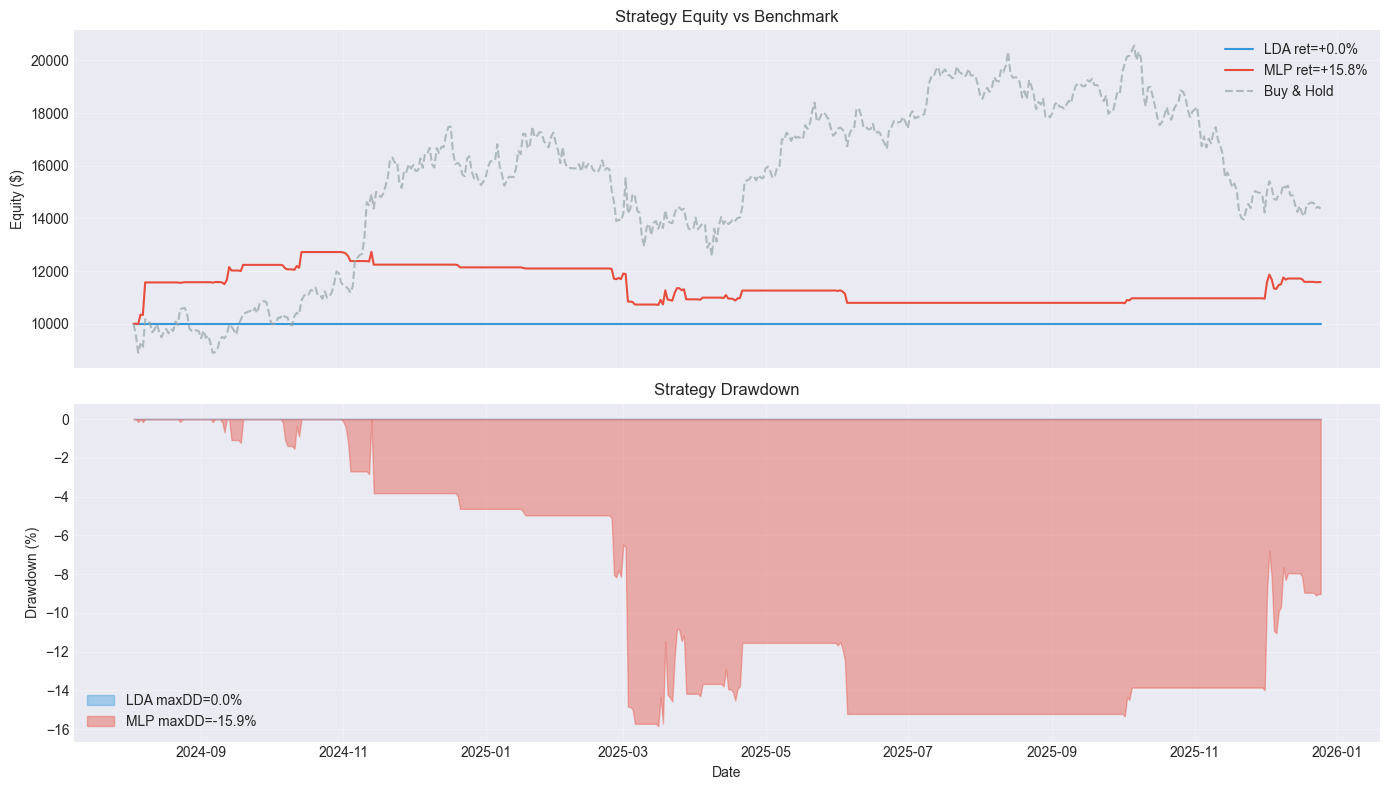

In [6]:
# Drawdown plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for label, result, color in [("LDA", lda_with, "#3498DB"), ("MLP", mlp_with, "#E74C3C")]:
    eq = result["equity_curve"]
    cummax = eq.cummax()
    dd = (eq - cummax) / cummax * 100
    axes[0].plot(eq.index, eq.values, label=f"{label} ret={result['total_return']:+.1%}", color=color, linewidth=1.5)
    axes[1].fill_between(dd.index, dd.values, 0, color=color, alpha=0.4, label=f"{label} maxDD={result['max_drawdown']:.1%}")

axes[0].plot(bh_equity.index, bh_equity.values, label="Buy & Hold", color="#95A5A6", linestyle="--", alpha=0.7)
axes[0].set_ylabel("Equity ($)"); axes[0].set_title("Strategy Equity vs Benchmark"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel("Drawdown (%)"); axes[1].set_xlabel("Date"); axes[1].set_title("Strategy Drawdown"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "backtest_drawdowns.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Save backtest summary

In [7]:
save_csv(summary, PROJECT_ROOT / "data" / "labels" / "btc_backtest_summary.csv")

# Also save equity curves
equity_df = pd.DataFrame({
    "lda_equity": lda_with["equity_curve"],
    "mlp_equity": mlp_with["equity_curve"],
    "buy_hold": bh_equity,
})
save_csv(equity_df, PROJECT_ROOT / "data" / "labels" / "btc_equity_curves.csv")

print("Saved backtest summary + equity curves.")
print()
print(summary.to_string())

Saved backtest summary + equity curves.

                 total_return  annualized_return  sharpe_ratio  max_drawdown  n_trades  win_rate  profit_factor  transaction_fee  slippage
strategy                                                                                                                                  
LDA (with cost)        0.0000              0.000        0.0000        0.0000         0    0.0000         0.0000            0.001    0.0005
LDA (no cost)          0.0000              0.000        0.0000        0.0000         0    0.0000         0.0000            0.001    0.0005
MLP (with cost)        0.1582              0.076        0.5531       -0.1585        26    0.5385         1.6567            0.001    0.0005
MLP (no cost)          0.1582              0.076        0.5531       -0.1585        26    0.5385         1.6567            0.001    0.0005
Buy & Hold             0.4376                NaN        0.6653       -0.3215         1       NaN            NaN              

## Checkpoint #4 — backtest yorumu

### bakılacak
- LDA / MLP stratejileri Buy & Hold'u geçiyor mu (test period'da BTC kazandığı için zorlu benchmark)
- Sharpe ratio > 0 (riske göre düzeltilmiş kazanç)
- Maximum drawdown abartılı değil mi (>%50 kötü)
- Trade sayısı çok mu yüksek (overtrade riski) — transaction cost gerçek etkisi